C:\Users\alefe\AppData\Local\Temp\ipykernel_4920\3523292104.py:20: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df["fecha"] = pd.to_datetime(df["fecha"], dayfirst=True)
C:\Users\alefe\AppData\Local\Temp\ipykernel_4920\3523292104.py:54: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  metricas = df.groupby("cripto_id").apply(calcular_metricas).reset_index()


Criptomonedas en el dataset: ['BTC' 'DOGE' 'NEO' 'UNI' 'ZEN']
Métricas guardadas en: ../datos/procesados/metricas_criptos.csv
  cripto_id   precio_medio  volatilidad  retorno_promedio  drawdown_max  \
0       BTC  341687.222919    21.216388          1.509062     9100324.0   
1      DOGE  162833.633910    60.192963          5.236235      992752.0   
2       NEO  193677.864739   265.397254         14.947273      996136.0   
3       UNI  382469.244920    47.453290          4.614352      998396.0   
4       ZEN  233016.695666  1800.406553         41.217239     2028337.0   

   ratio_riesgo_retorno  
0              0.071127  
1              0.086991  
2              0.056320  
3              0.097240  
4              0.022893  


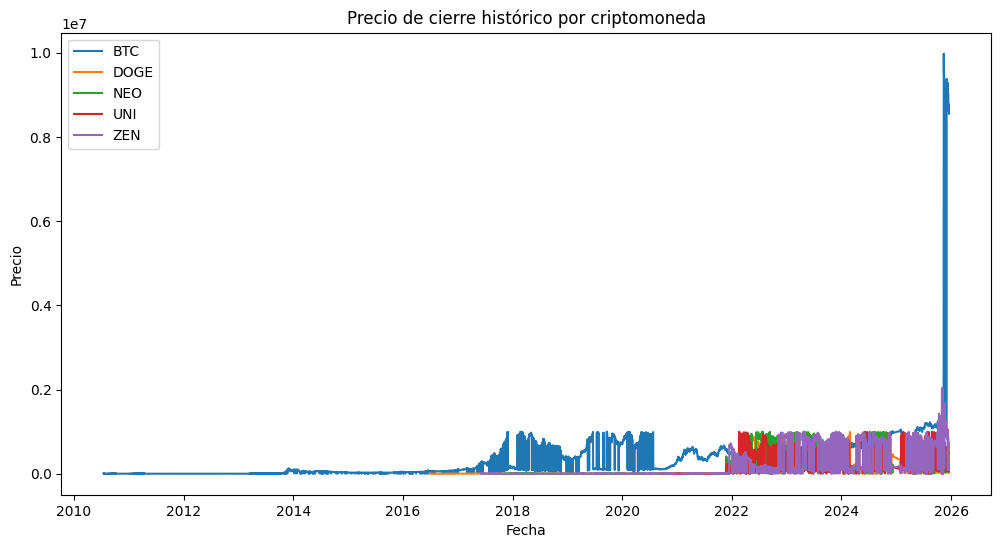

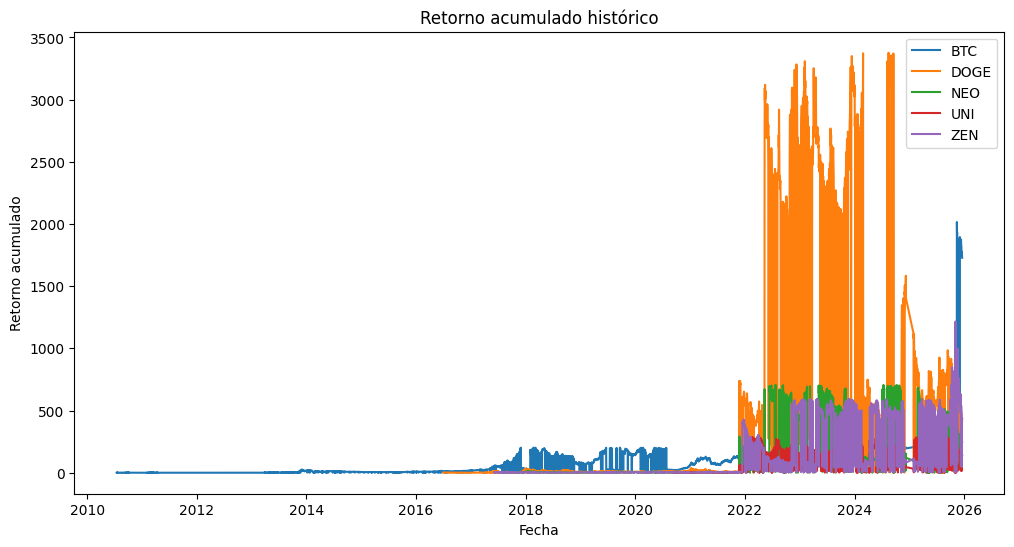

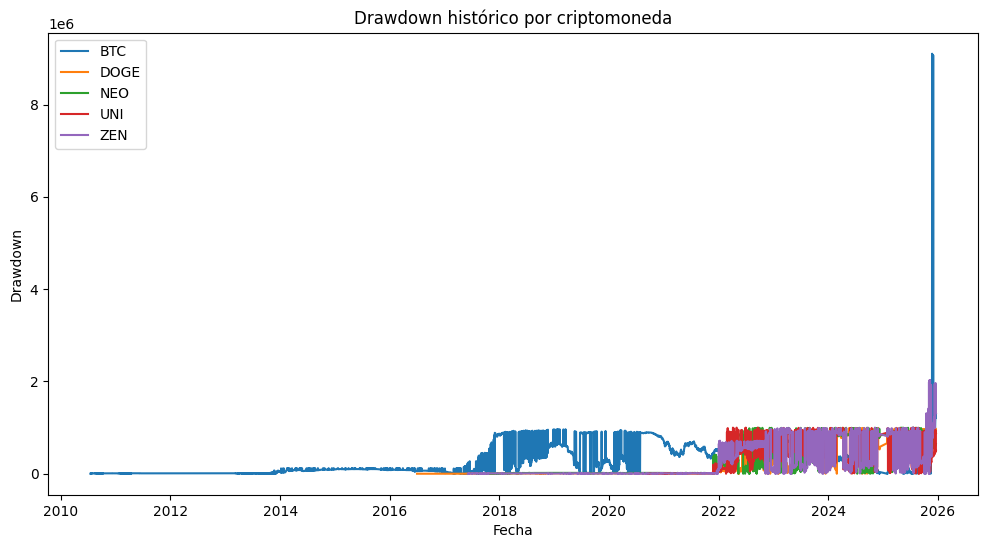

In [1]:
# 02_analisis_metricas.ipynb
# Análisis financiero de criptomonedas
# Calcula métricas clave y genera CSV listo para dashboards

import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

# -----------------------------
# 1. Configuración de rutas
# -----------------------------
ruta_csv = "../datos/procesados/precios_diarios.csv"
ruta_metricas = "../datos/procesados/metricas_criptos.csv"

# -----------------------------
# 2. Cargar dataset unificado
# -----------------------------
df = pd.read_csv(ruta_csv, encoding="utf-8", sep=';')
df["fecha"] = pd.to_datetime(df["fecha"], dayfirst=True)

# Ordenar por cripto y fecha
df = df.sort_values(["cripto_id", "fecha"]).reset_index(drop=True)

# Revisar criptos incluidas
print("Criptomonedas en el dataset:", df["cripto_id"].unique())

# -----------------------------
# 3. Calcular retorno diario
# -----------------------------
df["retorno_diario"] = df.groupby("cripto_id")["cierre"].pct_change()

# -----------------------------
# 4. Calcular drawdown diario
# -----------------------------
df["cierre_max"] = df.groupby("cripto_id")["cierre"].cummax()
df["drawdown"] = df["cierre_max"] - df["cierre"]

# -----------------------------
# 5. Función para métricas por cripto
# -----------------------------
def calcular_metricas(grupo):
    retorno = grupo["retorno_diario"].dropna()
    drawdown_max = grupo["drawdown"].max()
    return pd.Series({
        "precio_medio": grupo["cierre"].mean(),
        "volatilidad": retorno.std(),
        "retorno_promedio": retorno.mean(),
        "drawdown_max": drawdown_max,
        "ratio_riesgo_retorno": retorno.mean() / retorno.std() if retorno.std() != 0 else np.nan
    })

# Aplicar por cripto
metricas = df.groupby("cripto_id").apply(calcular_metricas).reset_index()

# -----------------------------
# 6. Guardar métricas en CSV
# -----------------------------
metricas.to_csv(ruta_metricas, index=False, encoding="utf-8", sep=';')
print("Métricas guardadas en:", ruta_metricas)
print(metricas)

# -----------------------------
# 7. Gráficos rápidos (opcional)
# -----------------------------
# Precio de cierre histórico
plt.figure(figsize=(12,6))
for cripto in df["cripto_id"].unique():
    subset = df[df["cripto_id"] == cripto]
    plt.plot(subset["fecha"], subset["cierre"], label=cripto)

plt.title("Precio de cierre histórico por criptomoneda")
plt.xlabel("Fecha")
plt.ylabel("Precio")
plt.legend()
plt.show()

# Retorno diario acumulado
plt.figure(figsize=(12,6))
for cripto in df["cripto_id"].unique():
    subset = df[df["cripto_id"] == cripto].copy()
    subset["retorno_acum"] = (1 + subset["retorno_diario"].fillna(0)).cumprod()
    plt.plot(subset["fecha"], subset["retorno_acum"], label=cripto)

plt.title("Retorno acumulado histórico")
plt.xlabel("Fecha")
plt.ylabel("Retorno acumulado")
plt.legend()
plt.show()

# Drawdown máximo por cripto
plt.figure(figsize=(12,6))
for cripto in df["cripto_id"].unique():
    subset = df[df["cripto_id"] == cripto]
    plt.plot(subset["fecha"], subset["drawdown"], label=cripto)

plt.title("Drawdown histórico por criptomoneda")
plt.xlabel("Fecha")
plt.ylabel("Drawdown")
plt.legend()
plt.show()
